# Calibration and Reliability Analysis

## Objective

This analysis evaluates the probability calibration and reliability of the selected classification models across three dataset configurations:

- **Demographics + Questionnaire:** Logistic Regression
- **Wearable + Questionnaire:** Random Forest
- **Full Multimodal:** XGBoost

Sigmoid and isotonic calibration methods are evaluated against the original uncalibrated probability estimates. Calibration is fitted using the validation dataset and evaluated on the independent test dataset.

Probability reliability is assessed using the multiclass Brier score, log loss, and class-specific calibration curves. Lower Brier scores and log loss values indicate better probabilistic performance. Both metrics are considered jointly when interpreting the effect of calibration.

## Importing libraries and setting paths 

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import log_loss

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "models"
METRICS_DIR = ROOT / "outputs" / "metrics"
FIGURES_DIR = ROOT / "outputs" / "figures"

METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)

Project root: /Users/user/Documents/GitHub/AI-Assisted-Screening-of-Parkinson-s-Disease


In [2]:
MODEL_CONFIG = {
    "Demographics + Questionnaire": {
        "model_name": "Logistic Regression",
        "model_path": MODEL_DIR / "demographics_plus_questionnaire_logistic_regression.joblib",
        "validation_path": DATA_DIR / "validation_demographics_questionnaire_task_aware.csv",
        "test_path": DATA_DIR / "test_demographics_questionnaire_task_aware.csv",
    },

    "Wearable + Questionnaire": {
        "model_name": "Random Forest",
        "model_path": MODEL_DIR / "wearable_plus_questionnaire_random_forest.joblib",
        "validation_path": DATA_DIR / "validation_wearable_questionnaire_task_aware.csv",
        "test_path": DATA_DIR / "test_wearable_questionnaire_task_aware.csv",
    },

    "Full Multimodal": {
        "model_name": "XGBoost",
        "model_path": MODEL_DIR / "full_multimodal_xgboost.joblib",
        "validation_path": DATA_DIR / "validation_multimodal_full_task_aware.csv",
        "test_path": DATA_DIR / "test_multimodal_full_task_aware.csv",
    },
}

In [3]:
for dataset_name, cfg in MODEL_CONFIG.items():
    print("\n", dataset_name)
    print("Model:", cfg["model_path"].exists(), cfg["model_path"])
    print("Validation:", cfg["validation_path"].exists(), cfg["validation_path"])
    print("Test:", cfg["test_path"].exists(), cfg["test_path"])


 Demographics + Questionnaire
Model: True /Users/user/Documents/GitHub/AI-Assisted-Screening-of-Parkinson-s-Disease/models/demographics_plus_questionnaire_logistic_regression.joblib
Validation: True /Users/user/Documents/GitHub/AI-Assisted-Screening-of-Parkinson-s-Disease/data/processed/validation_demographics_questionnaire_task_aware.csv
Test: True /Users/user/Documents/GitHub/AI-Assisted-Screening-of-Parkinson-s-Disease/data/processed/test_demographics_questionnaire_task_aware.csv

 Wearable + Questionnaire
Model: True /Users/user/Documents/GitHub/AI-Assisted-Screening-of-Parkinson-s-Disease/models/wearable_plus_questionnaire_random_forest.joblib
Validation: True /Users/user/Documents/GitHub/AI-Assisted-Screening-of-Parkinson-s-Disease/data/processed/validation_wearable_questionnaire_task_aware.csv
Test: True /Users/user/Documents/GitHub/AI-Assisted-Screening-of-Parkinson-s-Disease/data/processed/test_wearable_questionnaire_task_aware.csv

 Full Multimodal
Model: True /Users/user/Do

In [4]:
for dataset_name, cfg in MODEL_CONFIG.items():
    val_df = pd.read_csv(cfg["validation_path"])
    test_df = pd.read_csv(cfg["test_path"])

    print(
        dataset_name,
        "| validation total_symptom_count:",
        "total_symptom_count" in val_df.columns,
        "| test:",
        "total_symptom_count" in test_df.columns,
    )

Demographics + Questionnaire | validation total_symptom_count: False | test: False
Wearable + Questionnaire | validation total_symptom_count: False | test: False
Full Multimodal | validation total_symptom_count: False | test: False


In [5]:
df = pd.read_csv(
    DATA_DIR / "validation_demographics_questionnaire_task_aware.csv"
)

print(df.columns.tolist())

['patient_id', 'study_id', 'condition_original', 'condition_group', 'label', 'age', 'height_cm', 'weight_kg', 'gender', 'handedness', 'family_history_any', 'family_history_first_degree', 'alcohol_effect_on_tremor', 'duplicate_patient_id', 'questionnaire_name', 'Q01', 'Q02', 'Q03', 'Q04', 'Q05', 'Q06', 'Q07', 'Q08', 'Q09', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28', 'Q29', 'Q30', 'questions_answered', 'questions_missing', 'questionnaire_status', 'gastrointestinal_count', 'urinary_count', 'pain_count', 'miscellaneous_count', 'apathy_attention_memory_count', 'distortion_perception_count', 'depression_anxiety_count', 'sexual_function_count', 'cardiovascular_count', 'sleep_fatigue_count']


In [6]:
prepared_data = {}

for dataset_name, cfg in MODEL_CONFIG.items():

    # Load saved model
    model = joblib.load(cfg["model_path"])

    # Load validation and test datasets
    val_df = pd.read_csv(cfg["validation_path"])
    test_df = pd.read_csv(cfg["test_path"])

    # Exact features expected by this saved model
    features = list(model.feature_names_in_)

    # Check for missing features BEFORE continuing
    missing_val = [f for f in features if f not in val_df.columns]
    missing_test = [f for f in features if f not in test_df.columns]

    print("\n" + "=" * 70)
    print(dataset_name)
    print("Expected features:", len(features))
    print("Missing validation features:", len(missing_val))
    print("Missing test features:", len(missing_test))

    if missing_val:
        print("Validation missing:", missing_val[:10])

    if missing_test:
        print("Test missing:", missing_test[:10])

    # Only prepare data if everything matches
    if not missing_val and not missing_test:

        X_val = val_df[features].copy()
        y_val = val_df["label"].copy()

        X_test = test_df[features].copy()
        y_test = test_df["label"].copy()

        prepared_data[dataset_name] = {
            "model": model,
            "X_val": X_val,
            "y_val": y_val,
            "X_test": X_test,
            "y_test": y_test
        }

        print("X_val shape:", X_val.shape)
        print("X_test shape:", X_test.shape)
        print("Validation labels:", sorted(y_val.unique()))
        print("Test labels:", sorted(y_test.unique()))
        print("STATUS: READY")


Demographics + Questionnaire
Expected features: 51
Missing validation features: 0
Missing test features: 0
X_val shape: (70, 51)
X_test shape: (71, 51)
Validation labels: [np.int64(0), np.int64(1), np.int64(2)]
Test labels: [np.int64(0), np.int64(1), np.int64(2)]
STATUS: READY

Wearable + Questionnaire
Expected features: 2397
Missing validation features: 0
Missing test features: 0
X_val shape: (70, 2397)
X_test shape: (71, 2397)
Validation labels: [np.int64(0), np.int64(1), np.int64(2)]
Test labels: [np.int64(0), np.int64(1), np.int64(2)]
STATUS: READY

Full Multimodal
Expected features: 2405
Missing validation features: 0
Missing test features: 0
X_val shape: (70, 2405)
X_test shape: (71, 2405)
Validation labels: [np.int64(0), np.int64(1), np.int64(2)]
Test labels: [np.int64(0), np.int64(1), np.int64(2)]
STATUS: READY



## Baseline Probability Evaluation
The best-performing model for each dataset is evaluated for probability calibration. Calibration is fitted using the validation set, while the independent test set is reserved for final evaluation. Multiclass Brier score and log loss are used to assess probability reliability, where lower values indicate better calibrated probabilities.

In [7]:
def multiclass_brier_score(y_true, y_prob, classes):
    """
    Calculate multiclass Brier score.
    Lower values indicate better probability calibration.
    """
    y_true = np.asarray(y_true)

    y_onehot = np.zeros_like(y_prob, dtype=float)

    for i, cls in enumerate(classes):
        y_onehot[:, i] = (y_true == cls).astype(float)

    return np.mean(
        np.sum((y_prob - y_onehot) ** 2, axis=1)
    )

In [8]:
# Evaluating original models before calibration
uncalibrated_results = []
uncalibrated_probabilities = {}

for dataset_name, data in prepared_data.items():

    model = data["model"]
    X_test = data["X_test"]
    y_test = data["y_test"]

    probabilities = model.predict_proba(X_test)
    classes = model.classes_

    brier = multiclass_brier_score(
        y_test,
        probabilities,
        classes
    )

    ll = log_loss(
        y_test,
        probabilities,
        labels=classes
    )

    uncalibrated_probabilities[dataset_name] = probabilities

    uncalibrated_results.append({
        "Dataset": dataset_name,
        "Model": MODEL_CONFIG[dataset_name]["model_name"],
        "Calibration": "Uncalibrated",
        "Brier_Score": brier,
        "Log_Loss": ll
    })

uncalibrated_df = pd.DataFrame(uncalibrated_results)

uncalibrated_df

,Dataset,Model,Calibration,Brier_Score,Log_Loss
0,Demographics + Questionnaire,Logistic Regression,Uncalibrated,0.485903,0.790654
1,Wearable + Questionnaire,Random Forest,Uncalibrated,0.396048,0.676139
2,Full Multimodal,XGBoost,Uncalibrated,0.394172,0.635368


## Fit Sigmoid calibration

In [9]:
sigmoid_models = {}
sigmoid_probabilities = {}
sigmoid_results = []

for dataset_name, data in prepared_data.items():

    print("Calibrating:", dataset_name)

    model = data["model"]

    X_val = data["X_val"]
    y_val = data["y_val"]

    X_test = data["X_test"]
    y_test = data["y_test"]

    frozen_model = FrozenEstimator(model)

    calibrated_model = CalibratedClassifierCV(
        frozen_model,
        method="sigmoid"
    )

    calibrated_model.fit(X_val, y_val)

    probabilities = calibrated_model.predict_proba(X_test)

    classes = calibrated_model.classes_

    brier = multiclass_brier_score(
        y_test,
        probabilities,
        classes
    )

    ll = log_loss(
        y_test,
        probabilities,
        labels=classes
    )

    sigmoid_models[dataset_name] = calibrated_model
    sigmoid_probabilities[dataset_name] = probabilities

    sigmoid_results.append({
        "Dataset": dataset_name,
        "Model": MODEL_CONFIG[dataset_name]["model_name"],
        "Calibration": "Sigmoid",
        "Brier_Score": brier,
        "Log_Loss": ll
    })

sigmoid_df = pd.DataFrame(sigmoid_results)

sigmoid_df

Calibrating: Demographics + Questionnaire
Calibrating: Wearable + Questionnaire
Calibrating: Full Multimodal


,Dataset,Model,Calibration,Brier_Score,Log_Loss
0,Demographics + Questionnaire,Logistic Regression,Sigmoid,0.437892,0.733730
1,Wearable + Questionnaire,Random Forest,Sigmoid,0.356914,0.602310
2,Full Multimodal,XGBoost,Sigmoid,0.406197,0.688446


## Fit Isotonic calibration

In [10]:
isotonic_models = {}
isotonic_probabilities = {}
isotonic_results = []

for dataset_name, data in prepared_data.items():

    print("Calibrating:", dataset_name)

    model = data["model"]

    X_val = data["X_val"]
    y_val = data["y_val"]

    X_test = data["X_test"]
    y_test = data["y_test"]

    frozen_model = FrozenEstimator(model)

    calibrated_model = CalibratedClassifierCV(
        frozen_model,
        method="isotonic"
    )

    calibrated_model.fit(X_val, y_val)

    probabilities = calibrated_model.predict_proba(X_test)

    classes = calibrated_model.classes_

    brier = multiclass_brier_score(
        y_test,
        probabilities,
        classes
    )

    ll = log_loss(
        y_test,
        probabilities,
        labels=classes
    )

    isotonic_models[dataset_name] = calibrated_model
    isotonic_probabilities[dataset_name] = probabilities

    isotonic_results.append({
        "Dataset": dataset_name,
        "Model": MODEL_CONFIG[dataset_name]["model_name"],
        "Calibration": "Isotonic",
        "Brier_Score": brier,
        "Log_Loss": ll
    })

isotonic_df = pd.DataFrame(isotonic_results)

isotonic_df

Calibrating: Demographics + Questionnaire
Calibrating: Wearable + Questionnaire
Calibrating: Full Multimodal


,Dataset,Model,Calibration,Brier_Score,Log_Loss
0,Demographics + Questionnaire,Logistic Regression,Isotonic,0.490095,4.966804
1,Wearable + Questionnaire,Random Forest,Isotonic,0.389807,2.479520
2,Full Multimodal,XGBoost,Isotonic,0.375431,1.064752


## Combining all calibration results

In [11]:
calibration_results = pd.concat(
    [
        uncalibrated_df,
        sigmoid_df,
        isotonic_df
    ],
    ignore_index=True
)

calibration_results

,Dataset,Model,Calibration,Brier_Score,Log_Loss
0,Demographics + Questionnaire,Logistic Regression,Uncalibrated,0.485903,0.790654
1,Wearable + Questionnaire,Random Forest,Uncalibrated,0.396048,0.676139
2,Full Multimodal,XGBoost,Uncalibrated,0.394172,0.635368
3,Demographics + Questionnaire,Logistic Regression,Sigmoid,0.437892,0.733730
4,Wearable + Questionnaire,Random Forest,Sigmoid,0.356914,0.602310
5,Full Multimodal,XGBoost,Sigmoid,0.406197,0.688446
6,Demographics + Questionnaire,Logistic Regression,Isotonic,0.490095,4.966804
7,Wearable + Questionnaire,Random Forest,Isotonic,0.389807,2.479520
8,Full Multimodal,XGBoost,Isotonic,0.375431,1.064752


## Comparison of Calibration Methods

The original uncalibrated probability estimates are compared with sigmoid and isotonic calibration using multiclass Brier score and log loss. The results are interpreted jointly across both metrics rather than selecting a calibration method based on a single performance measure.

## Comparing the Brier scores

In [12]:
brier_comparison = calibration_results.pivot(
    index=["Dataset", "Model"],
    columns="Calibration",
    values="Brier_Score"
)

brier_comparison

,Calibration,Isotonic,Sigmoid,Uncalibrated
Dataset,Model,,,
Demographics + Questionnaire,Logistic Regression,0.490095,0.437892,0.485903
Full Multimodal,XGBoost,0.375431,0.406197,0.394172
Wearable + Questionnaire,Random Forest,0.389807,0.356914,0.396048


## Comparing log loss

In [13]:
logloss_comparison = calibration_results.pivot(
    index=["Dataset", "Model"],
    columns="Calibration",
    values="Log_Loss"
)

logloss_comparison

,Calibration,Isotonic,Sigmoid,Uncalibrated
Dataset,Model,,,
Demographics + Questionnaire,Logistic Regression,4.966804,0.733730,0.790654
Full Multimodal,XGBoost,1.064752,0.688446,0.635368
Wearable + Questionnaire,Random Forest,2.479520,0.602310,0.676139


## Creating calibration curves

In [14]:
def plot_multiclass_calibration(
    dataset_name,
    model_name,
    y_true,
    probability_sets,
    classes
):

    fig, axes = plt.subplots(
        1,
        len(classes),
        figsize=(16, 5)
    )

    for idx, cls in enumerate(classes):

        ax = axes[idx]

        y_binary = (np.asarray(y_true) == cls).astype(int)

        ax.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            label="Perfect calibration"
        )

        for method_name, probabilities in probability_sets.items():

            prob_true, prob_pred = calibration_curve(
                y_binary,
                probabilities[:, idx],
                n_bins=5,
                strategy="quantile"
            )

            ax.plot(
                prob_pred,
                prob_true,
                marker="o",
                label=method_name
            )

        ax.set_title(f"Class {cls}")
        ax.set_xlabel("Mean predicted probability")
        ax.set_ylabel("Observed frequency")
        ax.legend()

    fig.suptitle(
        f"{dataset_name} – {model_name}\nCalibration Curves"
    )

    plt.tight_layout()

    filename = (
        dataset_name
        .lower()
        .replace(" + ", "_")
        .replace(" ", "_")
    )

    plt.savefig(
        FIGURES_DIR / f"calibration_{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

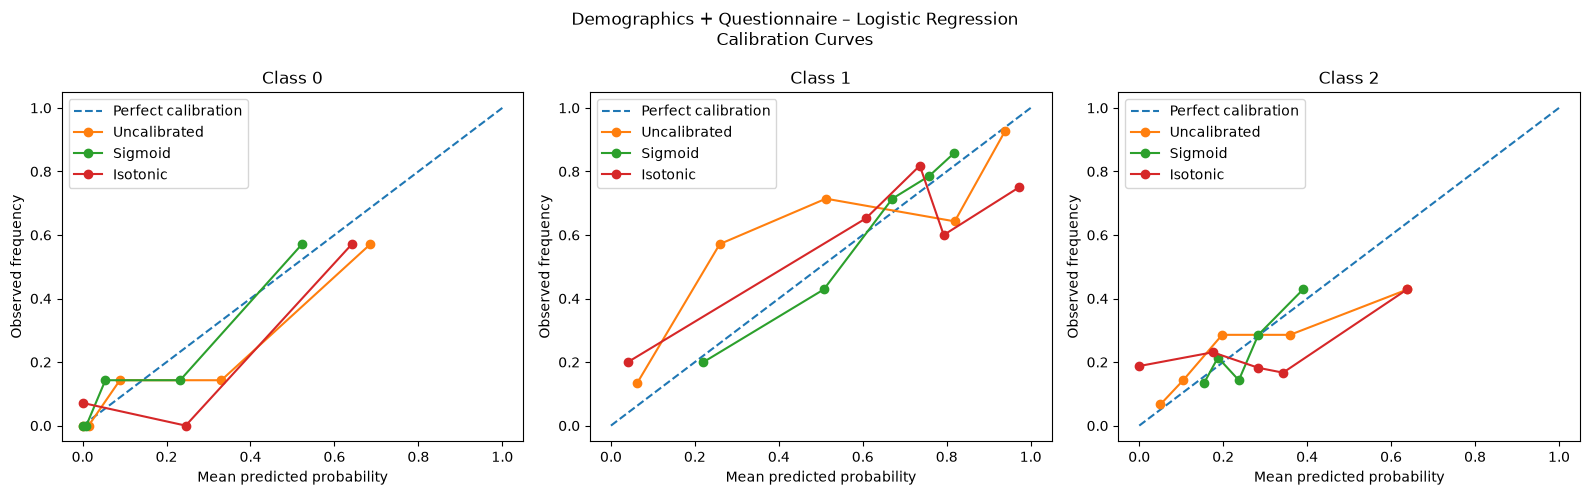

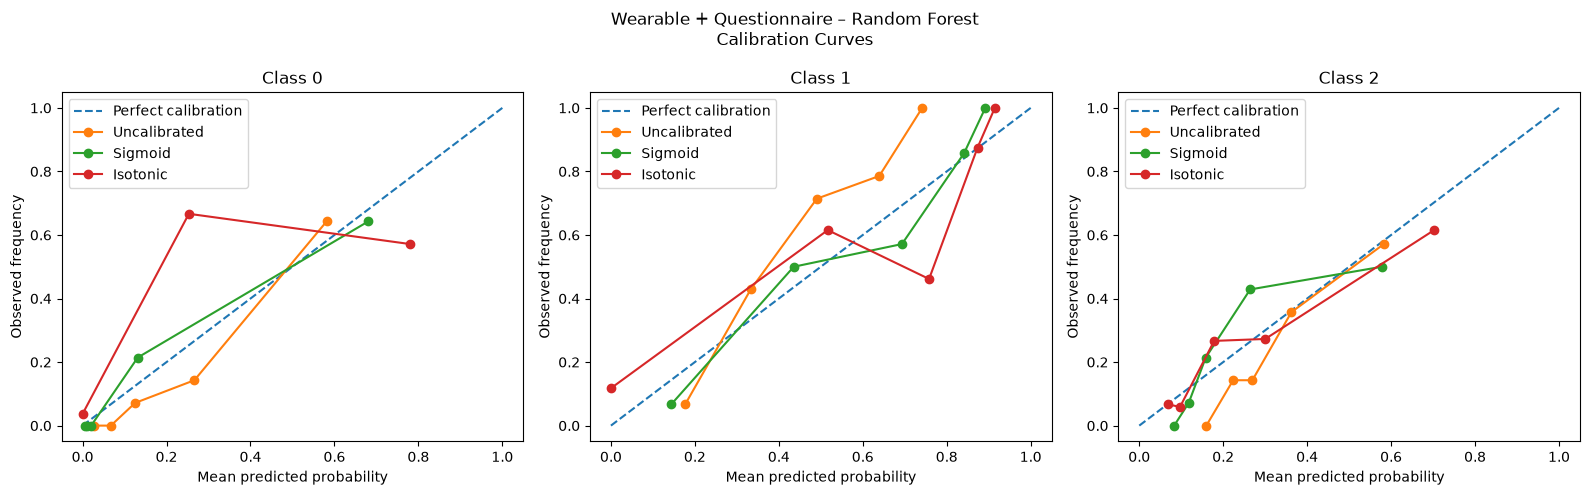

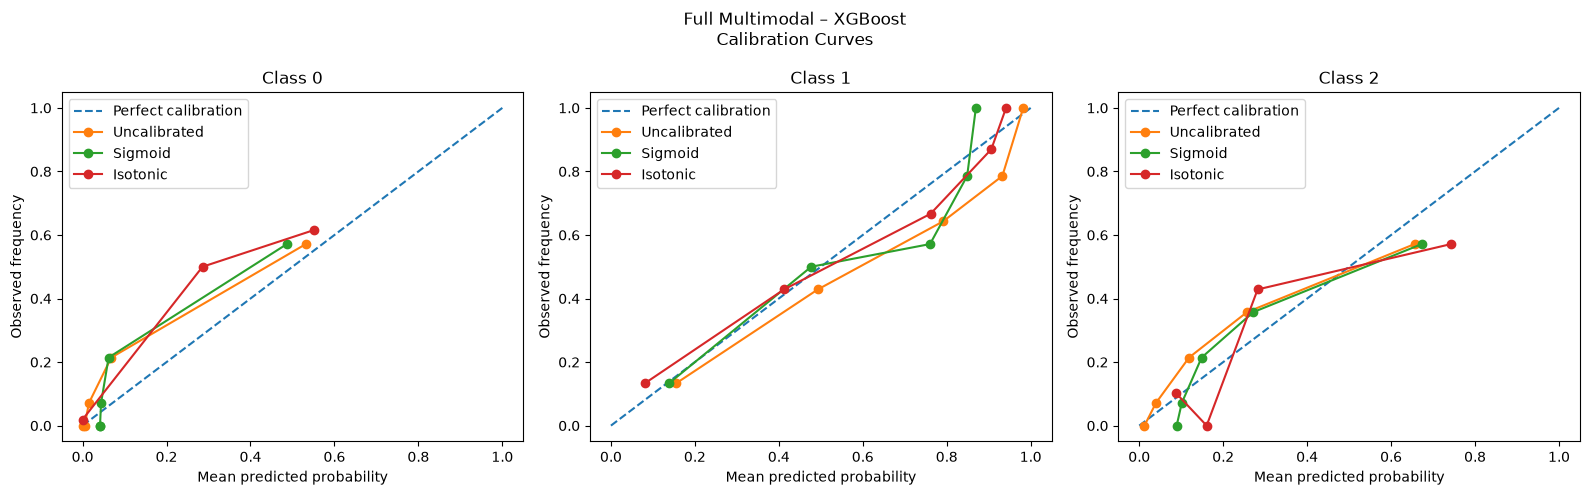

In [15]:
for dataset_name, data in prepared_data.items():

    model = data["model"]
    y_test = data["y_test"]

    probability_sets = {
        "Uncalibrated":
            uncalibrated_probabilities[dataset_name],

        "Sigmoid":
            sigmoid_probabilities[dataset_name],

        "Isotonic":
            isotonic_probabilities[dataset_name]
    }

    plot_multiclass_calibration(
        dataset_name=dataset_name,
        model_name=MODEL_CONFIG[dataset_name]["model_name"],
        y_true=y_test,
        probability_sets=probability_sets,
        classes=model.classes_
    )

In [16]:
calibration_results.to_csv(
    METRICS_DIR / "calibration_results.csv",
    index=False
)


print("Saved:")
print(METRICS_DIR / "calibration_results.csv")


Saved:
/Users/user/Documents/GitHub/AI-Assisted-Screening-of-Parkinson-s-Disease/outputs/metrics/calibration_results.csv


## Calibration Summary

Calibration was evaluated for the selected model associated with each dataset configuration: Logistic Regression for Demographics + Questionnaire, Random Forest for Wearable + Questionnaire, and XGBoost for Full Multimodal.

Sigmoid and isotonic calibration were fitted using the validation set, with probability reliability evaluated on the independent test set using multiclass Brier score, log loss, and calibration curves.

For the Demographics + Questionnaire Logistic Regression model, sigmoid calibration improved both the Brier score from 0.4859 to 0.4379 and log loss from 0.7907 to 0.7337.

For the Wearable + Questionnaire Random Forest model, sigmoid calibration improved both the Brier score from 0.3960 to 0.3569 and log loss from 0.6761 to 0.6023.

For the Full Multimodal XGBoost model, isotonic calibration reduced the Brier score from 0.3942 to 0.3754 but substantially increased log loss from 0.6354 to 1.0648. Sigmoid calibration did not improve either metric. Therefore, neither calibration method demonstrated a consistent improvement over the original XGBoost probabilities.

The original uncalibrated XGBoost probabilities were retained for subsequent analyses.